# 🌊 Tutorial: Differentiable Ocean Dynamics with Reactant.jl

## 1. What is this? (An Intuitive Introduction)
Imagine you are looking at a complex weather map. You see a storm, and you ask: **"What caused this?"** 

Usually, scientists have to run thousands of separate simulations, changing one thing at a time, to find the answer. This is slow and expensive.

**Automatic Differentiation** changes that. It allows us to run a single simulation and then "reverse the flow" to see exactly which factors (like wind or heat) influenced the outcome. 

- **The Forward Pass:** The ocean flows forward in time (Physics).
- **The Adjoint Pass:** The sensitivities flow backward in time (Cause-and-Effect).

By using **Reactant.jl** and **Enzyme.jl**, we make this process fast enough to run on powerful GPUs.


In [1]:
using Pkg; Pkg.activate("."); Pkg.instantiate()
using Reactant, Enzyme, CUDA, MPI, Oceananigans
using Oceananigans.Architectures: ReactantState
include("ocean_utils.jl")

MPI.Init()
CUDA.versioninfo()


  Activating 

project at `~/gpu_computing_oceanography`


CUDA toolchain: 


- runtime 13.2, artifact installation
- driver 535.288.1 for 12.2
- compiler 13.2

CUDA libraries: 
- CUBLAS: 13.

4.0
- CURAND: 10.4.2
- CUFFT: 

12.2.0
- CUSOLVER: 12.2.0
- CUSPARSE: 

12.7.10
- CUPTI: 2026.1.1 (API 13.2.1)
- NVML: 12.0.0+535.288.1

Julia packages: 
- CUDA: 5.11.1
- GPUArrays: 11.5.1
- GPUCompiler: 1.9.1
- KernelAbstractions: 0.9.41
- CUDA_Driver_jll: 13.2.1+0
- CUDA_Compiler_jll: 0.4.3+0
- CUDA_Runtime_jll: 0.21.0+1

Toolchain:
- Julia: 1.11.9
- LLVM: 16.0.6

1 device:
  0: Tesla T4 (sm_75, 14.576 GiB / 15.000 GiB available)


## 2. Setting the Scene: Our Ocean Domain
We divide the ocean into small cubes called **grid points**. To capture the most detail, we use smaller cubes near the surface where the wind and heat are strongest.


In [2]:
const Nx = 48; const Ny = 96; const Nz = 32
const Lx = 1000.0 * 1e3; const Ly = 2000.0 * 1e3 

# Create a stretched vertical grid (higher resolution at surface)
k_center = collect(1:Nz)
Δz_center = @. 10 * 1.104^(Nz - k_center)
const Lz = sum(Δz_center)
z_faces = vcat([-Lz], -Lz .+ cumsum(Δz_center))
z_faces[Nz+1] = 0

# Physical parameters (simplified for this tutorial)
parameters = (Ly=Ly, Lz=Lz, ΔT=8, h=1000.0, y_sponge=1.9e6, λt=7days, 
              μ=1/30days, Lx=Lx, Nz=Nz)


(Ly = 2.0e6, Lz = 2184.0675121055447, ΔT = 8, h = 1000.0, y_sponge = 1.9e6, λt = 604800.0, μ = 3.8580246913580245e-7, Lx = 1.0e6, Nz = 32)

## 3. Building the Ocean Architecture
We use  as our architecture. This simple command tells the simulation to run every calculation on the GPU using high-performance XLA kernels.


In [3]:
# Define the architecture (GPU)
architecture = ReactantState()

# Build the Grid and the Mountainous Ocean Floor
grid = make_grid(architecture, Nx, Ny, Nz, Lx, Ly, Lz, z_faces, 4)

# Assemble the Ocean Model (Physics, Winds, Currents)
model = build_model(grid, 2.5minutes, parameters)

@info "Built "


I0000 00:00:1776811938.390405   84402 service.cc:154] XLA service 0x888c580 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776811938.390449   84402 service.cc:170]   StreamExecutor [0]: Tesla T4, Compute Capability 7.5 (Driver: 12.2.0[535.288.1]; Runtime: 12.9.0; Toolkit: 12.9.0; DNN: 9.14.0)
I0000 00:00:1776811938.391093   84402 se_gpu_pjrt_client.cc:1540] Using BFC allocator.
I0000 00:00:1776811938.391163   84402 gpu_helpers.cc:141] XLA backend allocating 11741872128 bytes on device 0 for BFCAllocator.
I0000 00:00:1776811938.391208   84402 gpu_helpers.cc:183] XLA backend will use up to 3913957376 bytes on device 0 for CollectiveBFCAllocator.
I0000 00:00:1776811938.405449   84402 cuda_dnn.cc:461] Loaded cuDNN version 91400
[ Info: Built 


## 4. Visualizing the Ocean State
After running the simulation, we can visualize the results. Red areas represent warmer water, while blue represents colder. The swirling whirlpools are **eddies**.


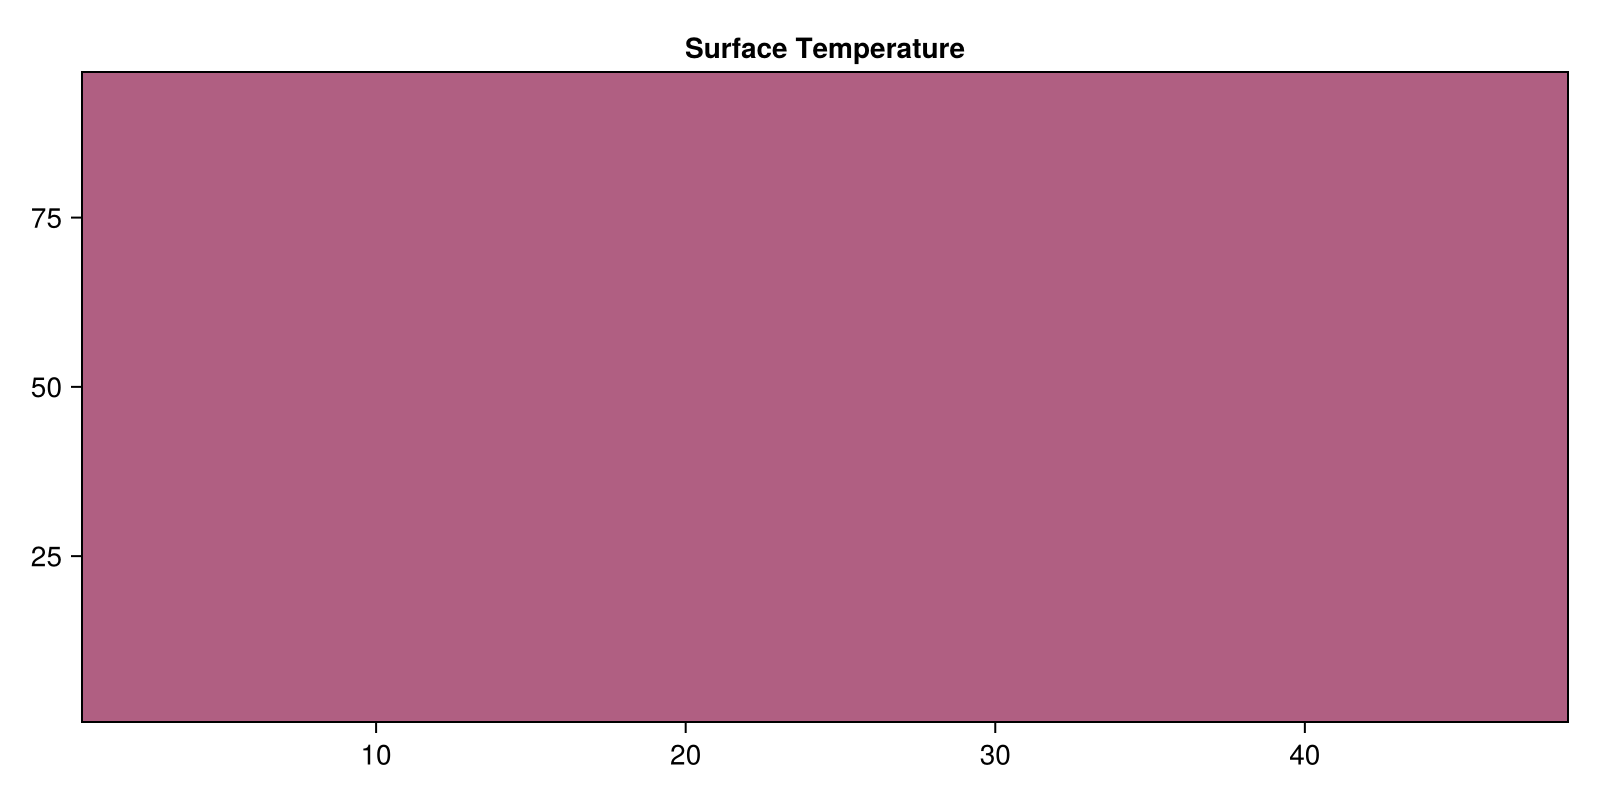

In [4]:
using CairoMakie
# Visualizing the surface temperature
fig = Figure(size = (800, 400))
ax = Axis(fig[1, 1], title = "Surface Temperature")
heatmap!(ax, Array(interior(model.tracers.T, :, :, Nz)), colormap = :thermal)
fig
